Лабораторна робота №4

Виконав: Верещака Олександр ПР-2-2
Варіант №1

### Хід роботи

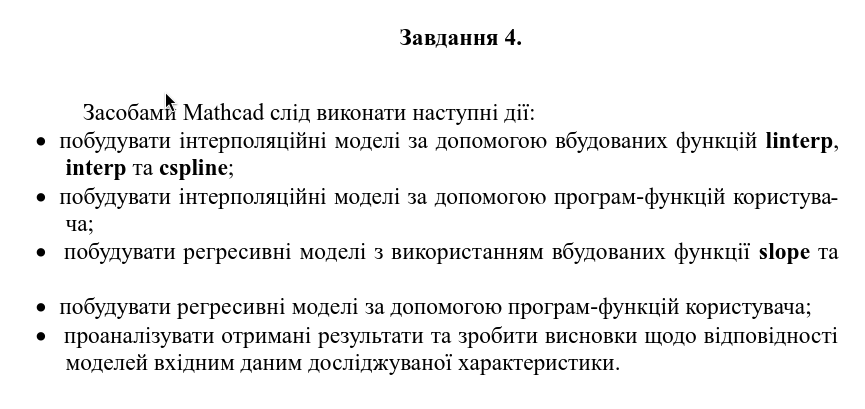

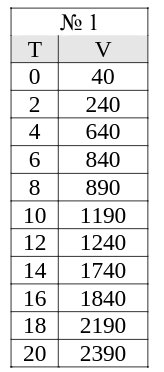

R-squared for Manual Linear Regression: 0.9854


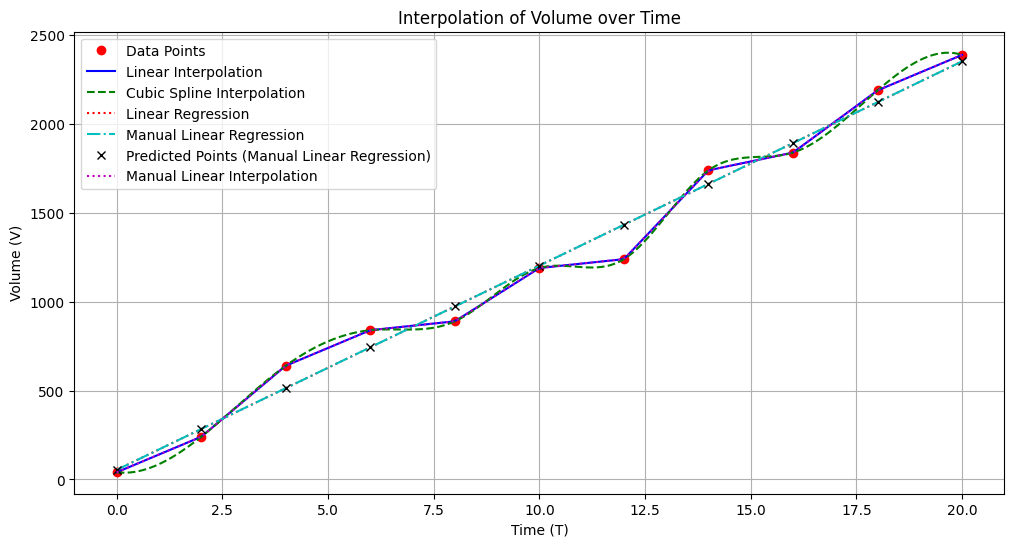

In [5]:
# task 4.1
import numpy as np
import scipy.interpolate as interp
import matplotlib.pyplot as plt

T = [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20]
V = [40, 240, 640, 840, 890, 1190, 1240, 1740, 1840, 2190, 2390]

x = np.linspace(T[0], T[-1], 200)

# ==========================================
# 1. Метод лінійної інтерполяції
# ==========================================

linterp = np.interp(x, T, V)

# ==========================================
# 2. Метод кубічної сплайн-інтерполяції
# ==========================================

cs = interp.CubicSpline(T, V)
y_spline = cs(x)

# ==========================================
# 3. Метод лінійної регресії
# ==========================================

linregression = np.polyfit(T, V, 1)
y_linreg = np.polyval(linregression, x)

# ==========================================
# 4. Метод лінійної інтерполяції
# ==========================================

S1 = np.sum(T)
S2 = np.sum(np.array(T) ** 2)
S3 = np.sum(V)
S4 = np.sum(np.array(T) * np.array(V))

a0 = (S2 * S3 - S1 * S4) / (len(T) * S2 - S1**2)
a1 = (len(T) * S4 - S1 * S3) / (len(T) * S2 - S1**2)
y_manual_linreg = a0 + a1 * np.array(x)
V_pred_manual_linreg = a0 + a1 * np.array(T)

Y_s = np.average(V)
D = np.sum((V - Y_s) ** 2)
D1 = np.sum((V - V_pred_manual_linreg) ** 2)
R_squared = 1 - D1 / D
print(f"R-squared for Manual Linear Regression: {R_squared:.4f}")


# ==========================================
# 5. Метод лінійної інтерполяції (ПРОГРАМА КОРИСТУВАЧА)
# ==========================================
def manual_linterp(x_grid, T_data, V_data):
    y_calc = []
    for x_val in x_grid:
        for i in range(len(T_data) - 1):
            if T_data[i] <= x_val <= T_data[i + 1]:
                y_val = V_data[i] + (
                    (V_data[i + 1] - V_data[i]) / (T_data[i + 1] - T_data[i])
                ) * (x_val - T_data[i])
                y_calc.append(y_val)
                break
    return np.array(y_calc)


y_manual_interp = manual_linterp(x, T, V)


plt.figure(figsize=(12, 6))
plt.plot(T, V, "ro", label="Data Points")
plt.plot(x, linterp, "b-", label="Linear Interpolation")
plt.plot(x, y_spline, "g--", label="Cubic Spline Interpolation")
plt.plot(x, y_linreg, "r:", label="Linear Regression")
plt.plot(x, y_manual_linreg, "c-.", label="Manual Linear Regression")
plt.plot(
    T, V_pred_manual_linreg, "kx", label="Predicted Points (Manual Linear Regression)"
)
plt.plot(x, y_manual_interp, "m:", label="Manual Linear Interpolation")
plt.xlabel("Time (T)")
plt.ylabel("Volume (V)")
plt.title("Interpolation of Volume over Time")
plt.legend()
plt.grid()
plt.show()

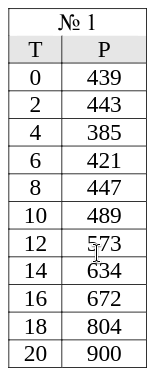

Коефіцієнт детермінації R^2: 0.8376


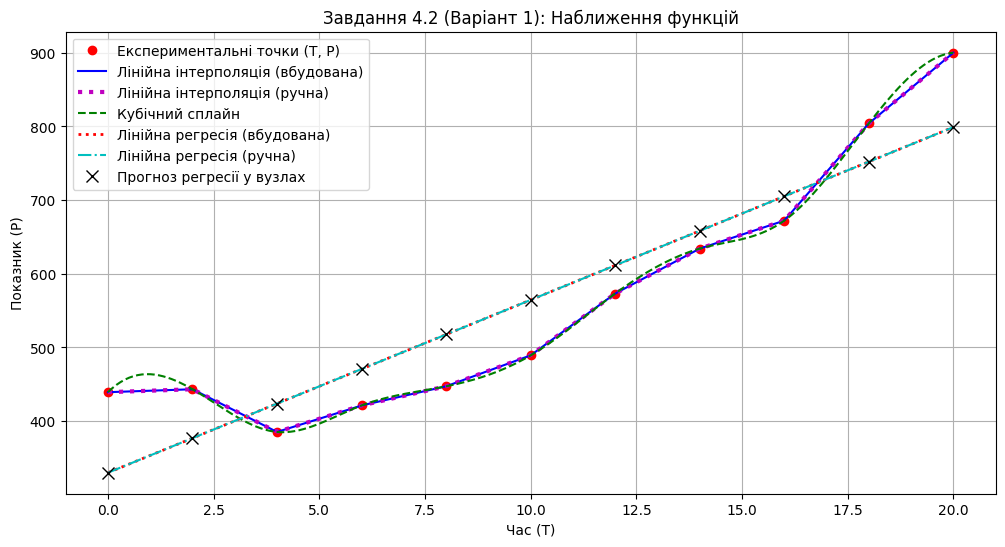

In [4]:
# ==========================================
# Завдання 4.2 (Варіант 1)
# ==========================================
import numpy as np
import scipy.interpolate as interp
import matplotlib.pyplot as plt

# Вхідні дані згідно з таблицею варіанта 1
T = [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20]
P = [439, 443, 385, 421, 447, 489, 573, 634, 672, 804, 900]

# Густа сітка для побудови плавних графіків
x = np.linspace(T[0], T[-1], 200)

# ==========================================
# 1. Метод лінійної інтерполяції (Вбудована функція)
# ==========================================
linterp = np.interp(x, T, P)


# ==========================================
# 2. Метод лінійної інтерполяції (ПРОГРАМА КОРИСТУВАЧА)
# ==========================================
def manual_linterp(x_grid, T_data, P_data):
    y_calc = []
    for x_val in x_grid:
        for i in range(len(T_data) - 1):
            if T_data[i] <= x_val <= T_data[i + 1]:
                y_val = P_data[i] + (
                    (P_data[i + 1] - P_data[i]) / (T_data[i + 1] - T_data[i])
                ) * (x_val - T_data[i])
                y_calc.append(y_val)
                break
    return np.array(y_calc)


y_manual_interp = manual_linterp(x, T, P)

# ==========================================
# 3. Метод кубічної сплайн-інтерполяції
# ==========================================
cs = interp.CubicSpline(T, P)
y_spline = cs(x)

# ==========================================
# 4. Метод лінійної регресії (Вбудовані функції)
# ==========================================
linregression = np.polyfit(T, P, 1)
y_linreg = np.polyval(linregression, x)

# ==========================================
# 5. Метод лінійної регресії (ПРОГРАМА КОРИСТУВАЧА - МНК)
# ==========================================
S1 = np.sum(T)
S2 = np.sum(np.array(T) ** 2)
S3 = np.sum(P)
S4 = np.sum(np.array(T) * np.array(P))

a0 = (S2 * S3 - S1 * S4) / (len(T) * S2 - S1**2)
a1 = (len(T) * S4 - S1 * S3) / (len(T) * S2 - S1**2)
y_manual_linreg = a0 + a1 * np.array(x)
P_pred_manual_linreg = a0 + a1 * np.array(T)

# ==========================================
# 6. Оцінка адекватності моделі (R^2)
# ==========================================
Y_s = np.average(P)
D = np.sum((P - Y_s) ** 2)
D1 = np.sum((P - P_pred_manual_linreg) ** 2)
R_squared = 1 - D1 / D
print(f"Коефіцієнт детермінації R^2: {R_squared:.4f}")

# ==========================================
# 7. Побудова графіків
# ==========================================
plt.figure(figsize=(12, 6))
plt.plot(T, P, "ro", label="Експериментальні точки (T, P)")
plt.plot(x, linterp, "b-", label="Лінійна інтерполяція (вбудована)")
plt.plot(x, y_manual_interp, "m:", linewidth=3, label="Лінійна інтерполяція (ручна)")
plt.plot(x, y_spline, "g--", label="Кубічний сплайн")
plt.plot(x, y_linreg, "r:", linewidth=2, label="Лінійна регресія (вбудована)")
plt.plot(x, y_manual_linreg, "c-.", label="Лінійна регресія (ручна)")
plt.plot(T, P_pred_manual_linreg, "kx", markersize=8, label="Прогноз регресії у вузлах")

plt.xlabel("Час (T)")
plt.ylabel("Показник (P)")
plt.title("Завдання 4.2 (Варіант 1): Наближення функцій")
plt.legend()
plt.grid()
plt.show()